In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning

**Prerequisites you already have:** Python programming, Linear Algebra (vectors, matrices, dot products)

---
### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain what a regression problem is and how it differs from classification
2. Write down the hypothesis (model) function for linear regression
3. Derive and explain the Mean Squared Error (MSE) loss function
4. Understand Gradient Descent and the math behind the update rule
5. Implement linear regression **from scratch** using only NumPy (so you see every calculation)
6. Implement linear regression using **scikit-learn** (industry-standard tool)
7. Evaluate a model using MSE, and RMSE
8. Visualize predictions, residuals, and the loss curve 


# Part 1: What is a Regression Problem?

In Machine Learning, a **regression problem** is one where we try to predict a **continuous numeric value**.

| Problem | Type | Example Output |
|---|---|---|
| Predict house price from size | Regression | $250,000 |
| Predict tomorrow's temperature | Regression | 24.5°C |
| Predict if an email is spam | Classification | Yes/No |
| Predict digit in an image (0-9) | Classification | "7" |

**Linear Regression** specifically assumes the relationship between the input(s) and the output is a **straight line** (or a flat plane/hyperplane in higher dimensions).

### Real-world example we'll use today:
We want to predict a student's **exam score** based on the **number of hours they studied**. This is a simple, intuitive dataset to understand every formula clearly before moving to bigger, real datasets.


# Part 2: The Model — Hypothesis Function

## Simple Linear Regression (1 feature)

When we have **one input feature** $x$ (e.g., hours studied) and want to predict one output $y$ (e.g., exam score), we assume:

$$
\hat{y} = w \cdot x + b
$$

Where:
- $\hat{y}$ (y-hat) = the **predicted** value (our model's guess)
- $x$ = the input feature (hours studied)
- $w$ = the **weight** (also called *slope* or *coefficient*) — how much $y$ changes per unit of $x$
- $b$ = the **bias** (also called *intercept*) — the predicted value when $x = 0$

This is EXACTLY the equation of a straight line you learned in algebra: $y = mx + c$. In ML, we just rename $m \to w$ and $c \to b$.

---

## Multiple Linear Regression (many features) — where Linear Algebra comes in

Real datasets usually have many features. For example, predicting exam score from:
- Hours studied ($x_1$)
- Hours slept ($x_2$)
- Number of practice tests taken ($x_3$)

Now our model becomes:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

This generalizes to $n$ features:

$$
\hat{y} = \sum_{i=1}^{n} w_i x_i + b
$$

### Vectorized form (this is why Linear Algebra matters!)

Instead of writing a long sum, we use vectors:

$$
\hat{y} = \mathbf{w}^T \mathbf{x} + b
$$

Where $\mathbf{w} = [w_1, w_2, ..., w_n]$ and $\mathbf{x} = [x_1, x_2, ..., x_n]$ are vectors, and $\mathbf{w}^T \mathbf{x}$ is just the **dot product** you learned in Linear Algebra.

### For an entire dataset (matrix form)

If we have $m$ training examples, we stack them into a matrix $X$ (shape: $m \times n$), and:

$$
\hat{\mathbf{y}} = X\mathbf{w} + b
$$

This single matrix multiplication computes predictions for **all** data points at once — this is exactly why we studied matrix multiplication in linear algebra. Libraries like NumPy do this extremely fast.


In [2]:
# Let's make this concrete with actual numbers before writing any "learning" code.
import numpy as np

# Suppose we already KNOW good values for w and b (we'll learn them properly later)
w = 5      # slope: each extra hour of study adds 5 points
b = 50     # bias: base score with 0 hours studied

# One student studied 4 hours
x = 4
y_hat = w * x + b
print(f"Predicted score for a student who studied {x} hours: {y_hat}")

# Now let's do it for multiple students at once using vectors (this is the linear algebra part!)
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8])   # x vector
predictions = w * hours_studied + b                    # vectorized computation, no loop needed!
print("Predictions for all students:", predictions)


Predicted score for a student who studied 4 hours: 70
Predictions for all students: [55 60 65 70 75 80 85 90]


# Part 3: How do we know if our model is GOOD? — The Loss Function

Above, we just *picked* $w=5$ and $b=50$. But how do we know if these are the **best** values?

We need a way to measure **how wrong** our predictions are compared to the real, actual values. This measurement is called a **Loss Function** (or Cost Function).

## Residual (Error) for one point

For a single data point $i$:

$$
\text{error}_i = \hat{y}_i - y_i
$$

Where $y_i$ is the **actual/true** value and $\hat{y}_i$ is our **predicted** value.

### Why not just add up all the errors?

If we simply summed the errors, positive and negative errors would **cancel out**, making a bad model look good. For example, an error of $+10$ and an error of $-10$ would sum to $0$, hiding the fact that our model was off by 10 points on both.

## Mean Squared Error (MSE) — the standard loss for regression

We square each error (this makes it positive AND penalizes large errors more heavily), then average over all $m$ data points:

$$
MSE = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

### Breaking this formula down piece by piece:
1. $(\hat{y}_i - y_i)$ → how far off was prediction $i$?
2. $(\hat{y}_i - y_i)^2$ → squaring makes it positive, and penalizes big mistakes much more than small ones (an error of 10 becomes 100, an error of 2 becomes only 4)
3. $\sum_{i=1}^{m}$ → add up the squared errors for every one of the $m$ data points
4. $\frac{1}{m}$ → divide by the number of points to get the **average** — so MSE doesn't just get bigger with more data

**Goal of training:** Find the $w$ and $b$ that make MSE as **small as possible**.

This is why it's called the "loss" — it represents how much our model is "losing" (i.e., how wrong it is). A perfect model has $MSE = 0$.


In [3]:
# Let's calculate MSE by hand for our example above, then verify with a formula

# Actual exam scores (ground truth) for students who studied [1,2,3,4,5,6,7,8] hours
y_actual = np.array([54, 61, 64, 71, 74, 79, 86, 89])

# Our model's predictions from before (w=5, b=50)
y_pred = w * hours_studied + b
print("Predictions:", y_pred)
print("Actual:     ", y_actual)

# Step 1: calculate the error (residual) for each point
errors = y_pred - y_actual
print("\nErrors (predicted - actual):", errors)

# Step 2: square each error
squared_errors = errors ** 2
print("Squared errors:", squared_errors)

# Step 3 & 4: sum them up and divide by number of points (mean)
mse = np.mean(squared_errors)
print(f"\nMean Squared Error (MSE) = {mse:.2f}")

# We can also do this in one line using the formula directly:
mse_one_line = np.mean((y_pred - y_actual) ** 2)
print(f"MSE (one-liner check) = {mse_one_line:.2f}")


Predictions: [55 60 65 70 75 80 85 90]
Actual:      [54 61 64 71 74 79 86 89]

Errors (predicted - actual): [ 1 -1  1 -1  1  1 -1  1]
Squared errors: [1 1 1 1 1 1 1 1]

Mean Squared Error (MSE) = 1.00
MSE (one-liner check) = 1.00


# Part 4: Gradient Descent — How the Model Actually Learns

We know MSE tells us how wrong we are. But how do we find the $w$ and $b$ that make MSE the **smallest**?

## The Loss Surface (intuition first)

Imagine plotting MSE for every possible value of $w$ and $b$. This creates a bowl-shaped 3D surface (for linear regression, it's always a smooth "bowl" shape, mathematically called **convex**). Our goal is to find the lowest point of this bowl.

**Gradient Descent** is like standing on a foggy hillside and trying to reach the bottom: you can't see the whole landscape, but you can feel which direction is "downhill" right where you're standing. You take a small step in that direction, then repeat.

## The Math: Derivatives tell us the "downhill direction"

The **gradient** is just the derivative (slope) of the loss function with respect to each parameter. It tells us:
- Which direction increases the loss (uphill)
- How steep it is

Since we want to **decrease** loss, we move in the **opposite** direction of the gradient.

### Deriving the gradient for $w$ (calculus, explained step by step)

Our loss function (for simple linear regression, $\hat{y}_i = wx_i + b$):

$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(wx_i + b - y_i)^2
$$

Taking the partial derivative with respect to $w$ (using the chain rule):

$$
\frac{\partial \, MSE}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}(wx_i + b - y_i)\cdot x_i
$$

**In plain English:** this tells us, for each data point, how much increasing $w$ slightly would increase the loss, weighted by how large that data point's $x$ value is, then averaged over all points.

Similarly, the partial derivative with respect to $b$:

$$
\frac{\partial \, MSE}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}(wx_i + b - y_i)
$$

(Same idea, but without the extra $x_i$ multiplier, since $b$ affects every prediction equally.)

## The Update Rule

At each step, we nudge $w$ and $b$ a small amount in the *negative* gradient direction:

$$
w := w - \alpha \cdot \frac{\partial \, MSE}{\partial w}
$$
$$
b := b - \alpha \cdot \frac{\partial \, MSE}{\partial b}
$$

Where $\alpha$ (alpha) is the **learning rate** — a small number (e.g., 0.01) that controls **how big a step** we take.

- Too **large** a learning rate → we overshoot the bottom of the bowl and may never converge (or even diverge)
- Too **small** a learning rate → training is extremely slow, taking forever to reach the bottom

We repeat this update process for many **iterations** (also called **epochs**) until the loss stops decreasing significantly.


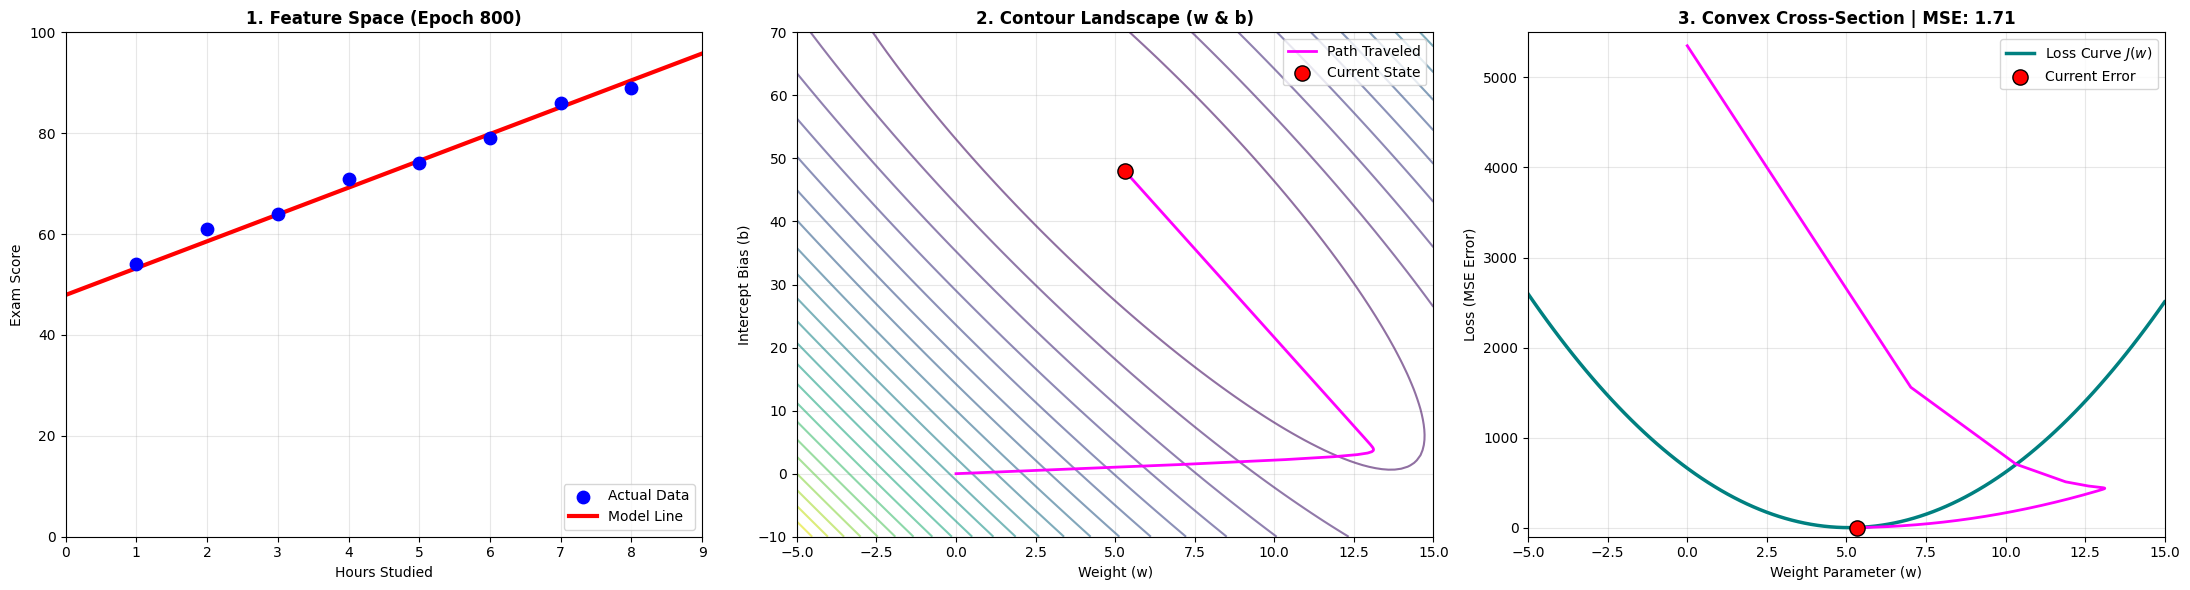

Optimization finished successfully! Final parameters: w = 5.3189, b = 47.9304


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

# 1. Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([54, 61, 64, 71, 74, 79, 86, 89], dtype=float)
m = len(X)

# 2. Pre-compute the 3D/2D Loss Landscape for background contours
w_vals = np.linspace(-5, 15, 100)
b_vals = np.linspace(-10, 70, 100)
W_grid, B_grid = np.meshgrid(w_vals, b_vals)
Loss_grid = np.zeros_like(W_grid)

for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        y_pred_grid = W_grid[i, j] * X + B_grid[i, j]
        Loss_grid[i, j] = np.mean((y_pred_grid - y) ** 2)

# Pre-compute the 2D Convex Curve for w ---
# We fix b at its target optimal value (~49.2) to showcase a perfect cross-section U-curve
fixed_b = 49.2321
loss_curve_w = []
for wi in w_vals:
    y_pred_curve = wi * X + fixed_b
    loss_curve_w.append(np.mean((y_pred_curve - y) ** 2))

# 3. Initialize Gradient Descent variables
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 801

# Track historical coordinates to trace paths
w_history = []
b_history = []
loss_history = []

for epoch in range(epochs):
    # Forward Pass & Loss tracking
    y_pred = w * X + b
    loss = np.mean((y_pred - y) ** 2)
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(loss)

    # Gradient Calculation
    dw = (2/m) * np.sum((y_pred - y) * X)
    db = (2/m) * np.sum((y_pred - y))

    # Parameter Update
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # ---- THREE-PANEL SIDE-BY-SIDE ANIMATION LOGIC ----
    if epoch % 20 == 0:
        display.clear_output(wait=True)
        
        # Setup 3 axes plot windows side-by-side
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
        
        # --- PANEL 1: Line Fitting (Feature Space) ---
        ax1.scatter(X, y, color='blue', s=80, zorder=5, label='Actual Data')
        X_line = np.linspace(0, 9, 100)
        ax1.plot(X_line, w * X_line + b, color='red', lw=3, label='Model Line')
        ax1.set_xlim(0, 9)
        ax1.set_ylim(0, 100)
        ax1.set_title(f"1. Feature Space (Epoch {epoch})", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Hours Studied")
        ax1.set_ylabel("Exam Score")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="lower right")
        
        # --- PANEL 2: Bird's-Eye View Topography (2 Parameters) ---
        ax2.contour(W_grid, B_grid, Loss_grid, levels=25, cmap='viridis', alpha=0.6)
        ax2.plot(w_history, b_history, color='magenta', linestyle='-', lw=2, label='Path Traveled')
        ax2.scatter(w, b, color='red', s=120, edgecolor='black', zorder=10, label='Current State')
        ax2.set_xlim(-5, 15)
        ax2.set_ylim(-10, 70)
        ax2.set_title(f"2. Contour Landscape (w & b)", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Weight (w)")
        ax2.set_ylabel("Intercept Bias (b)")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="upper right")
        
        # --- PANEL 3: NEW! Convex U-Curve Cross-Section (1 Parameter) ---
        ax3.plot(w_vals, loss_curve_w, color='teal', lw=2.5, label='Loss Curve $J(w)$')
        # Plot path traveled along the side of the bowl
        ax3.plot(w_history, loss_history, color='magenta', linestyle='-', lw=2)
        # Current status ball rolling down
        ax3.scatter(w, loss, color='red', s=120, edgecolor='black', zorder=10, label='Current Error')
        ax3.set_xlim(-5, 15)
        ax3.set_ylim(-100, 5500)
        ax3.set_title(f"3. Convex Cross-Section | MSE: {loss:.2f}", fontsize=12, fontweight='bold')
        ax3.set_xlabel("Weight Parameter (w)")
        ax3.set_ylabel("Loss (MSE Error)")
        ax3.grid(True, alpha=0.3)
        ax3.legend(loc="upper right")
        
        plt.tight_layout()
        plt.show()
        time.sleep(0.04)

print(f"Optimization finished successfully! Final parameters: w = {w:.4f}, b = {b:.4f}")

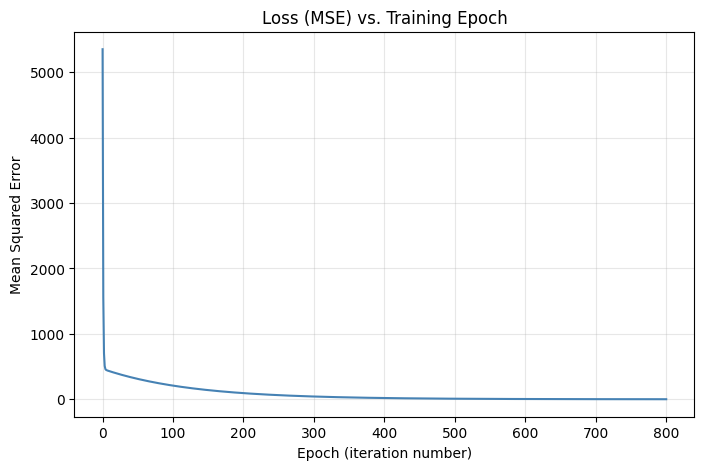

Notice: the loss drops FAST at first, then flattens out.
This flattening means gradient descent is converging -- it has nearly reached the bottom of the bowl.


In [5]:
# Visualize the Loss Curve: this shows the model LEARNING over time
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Loss (MSE) vs. Training Epoch")
plt.xlabel("Epoch (iteration number)")
plt.ylabel("Mean Squared Error")
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: the loss drops FAST at first, then flattens out.")
print("This flattening means gradient descent is converging -- it has nearly reached the bottom of the bowl.")


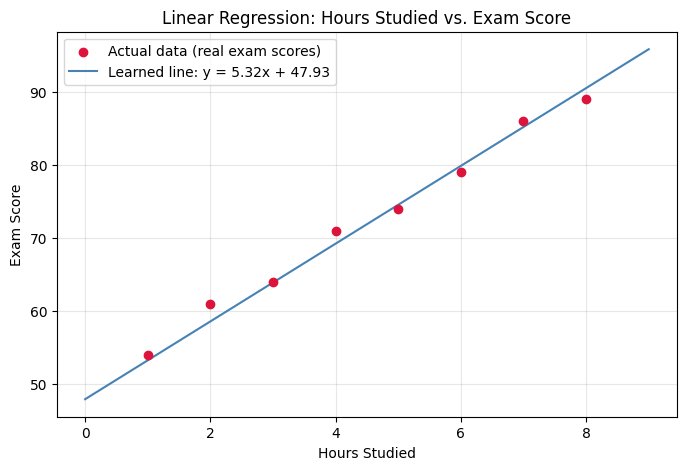

In [6]:
# Visualize the final fitted line against our actual data points
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='crimson', label='Actual data (real exam scores)', zorder=3)

x_line = np.linspace(0, 9, 100)
y_line = w * x_line + b
plt.plot(x_line, y_line, color='steelblue', label=f'Learned line: y = {w:.2f}x + {b:.2f}')

plt.title("Linear Regression: Hours Studied vs. Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Recap

| Concept | What it means |
|---|---|
| Hypothesis $\hat{y} = wx + b$ | Our model's equation for predicting a value |
| MSE Loss | A single number measuring how wrong our predictions are |
| Gradient | The derivative telling us which direction increases loss |
| Gradient Descent | Repeatedly stepping in the opposite (downhill) direction to reduce loss |
| Learning rate ($\alpha$) | How big each step is |
| Epoch | One full pass of updating $w$ and $b$ |

Take a short break here if needed — Hour 3 moves into practical, real-world coding using scikit-learn!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. THE DATASET (Predicting exam scores based on hours studied and attendance)
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
attendance_pct = np.array([50, 55, 60, 65, 70, 75, 80, 85], dtype=float)
actual_scores  = np.array([54, 61, 64, 71, 74, 79, 86, 89], dtype=float)
m = len(actual_scores)

# Feature Scaling (Shrinking numbers down so the AI doesn't get confused)
x1 = (hours_studied - np.mean(hours_studied)) / np.std(hours_studied)
x2 = (attendance_pct - np.mean(attendance_pct)) / np.std(attendance_pct)

# 2. STARTING GUESSES
bias = 0.0
w1 = 0.0
w2 = 0.0

learning_rate = 0.1
epochs = 60

# --- NEW: Digital Notebooks to record history ---
epoch_history = []
loss_history = []
bias_history = []
w1_history = []
w2_history = []

print("--- TRAINING STARTING ---")

# 3. THE LEARNING LOOP
for epoch in range(epochs):
    # Step A: Make a guess using the formula
    predicted_scores = bias + (w1 * x1) + (w2 * x2)
    
    # Step B: Calculate the Error (Loss)
    errors = predicted_scores - actual_scores
    loss = np.mean(errors ** 2)
    
    # --- Save the values for this step into our notebooks ---
    epoch_history.append(epoch)
    loss_history.append(loss)
    bias_history.append(bias)
    w1_history.append(w1)
    w2_history.append(w2)
    
    # Step C: Calculate the Direction to change the knobs (Gradients)
    d_bias = (2 / m) * np.sum(errors)
    d_w1   = (2 / m) * np.sum(errors * x1)
    d_w2   = (2 / m) * np.sum(errors * x2)
    
    # Step D: Update the knobs to do better next time
    bias = bias - (learning_rate * d_bias)
    w1   = w1 - (learning_rate * d_w1)
    w2   = w2 - (learning_rate * d_w2)
    
    # Print the progress every 20 steps
    if epoch % 10 == 0:
        print(f"Iteration {epoch:3d} | Loss: {loss:7.2f} | Bias: {bias:5.2f} | w1: {w1:4.2f} | w2: {w2:4.2f}")

print("\n--- TRAINING FINISHED! ---")

--- TRAINING STARTING ---
Iteration   0 | Loss: 5351.00 | Bias: 14.45 | w1: 2.28 | w2: 2.28
Iteration  10 | Loss:   61.12 | Bias: 66.04 | w1: 5.68 | w2: 5.68
Iteration  20 | Loss:    1.63 | Bias: 71.58 | w1: 5.70 | w2: 5.70
Iteration  30 | Loss:    0.94 | Bias: 72.18 | w1: 5.70 | w2: 5.70
Iteration  40 | Loss:    0.93 | Bias: 72.24 | w1: 5.70 | w2: 5.70
Iteration  50 | Loss:    0.93 | Bias: 72.25 | w1: 5.70 | w2: 5.70

--- TRAINING FINISHED! ---


Charts generated and saved successfully!


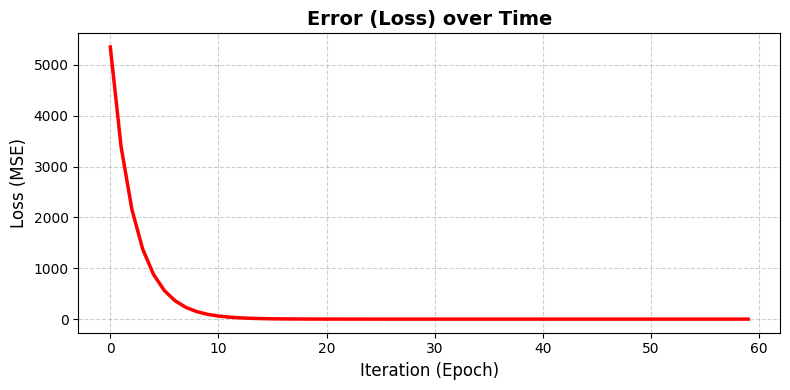

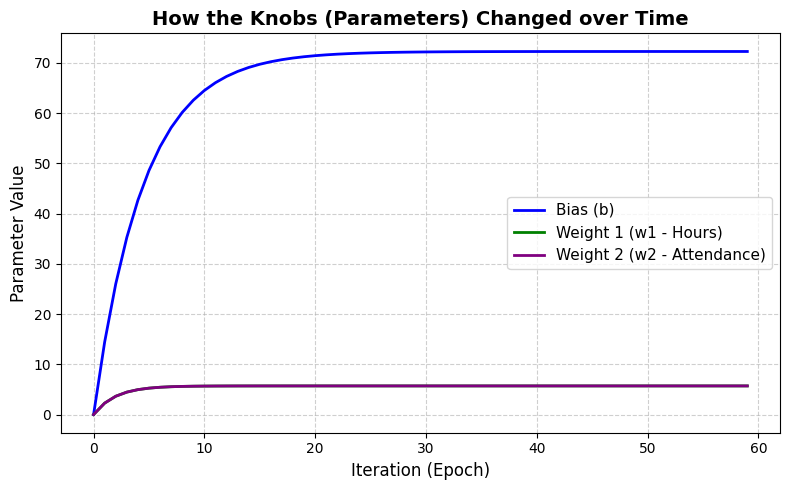

In [8]:
# 4. PLOTTING THE RESULTS
# Chart 1: The Loss Curve (Watching the errors drop)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epoch_history, loss_history, color='red', linewidth=2.5)
ax.set_title('Error (Loss) over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Iteration (Epoch)', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
#plt.savefig('loss_history.png')  # Saves the image
#plt.close()

# Chart 2: The Parameter Tracking (Watching the knobs move to the right spot)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epoch_history, bias_history, label='Bias (b)', color='blue', linewidth=2)
ax.plot(epoch_history, w1_history, label='Weight 1 (w1 - Hours)', color='green', linewidth=2)
ax.plot(epoch_history, w2_history, label='Weight 2 (w2 - Attendance)', color='purple', linewidth=2)
ax.set_title('How the Knobs (Parameters) Changed over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Iteration (Epoch)', fontsize=12)
ax.set_ylabel('Parameter Value', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
#plt.savefig('parameters_history.png')  # Saves the image
#plt.close()

print("Charts generated and saved successfully!")

---
# Hands-on Coding with scikit-learn

In earler step, we built linear regression completely **from scratch** so you understand every formula. In real ML work, we rarely write gradient descent by hand — instead we use well-tested libraries.

**scikit-learn** (`sklearn`) is the most widely used ML library in Python. It implements linear regression (and many other algorithms) with all the math we just learned handled internally and optimized for speed.

### What we'll do in this hour:
1. Load a real, slightly bigger dataset
2. Split it into **training** and **test** sets (and explain WHY this matters)
3. Train a Linear Regression model using scikit-learn (just a few lines!)
4. Make predictions
5. Evaluate the model using proper metrics: MSE, RMSE, R²
6. Visualize predictions vs. actual values, and residuals


## Step 1: Why do we split data into Train and Test sets? (See overfitting section)

If we train our model on ALL the data, and then test it on the SAME data, we have no way of knowing if the model actually **learned the pattern** or just **memorized** the specific data points it saw. This is called **overfitting**.

To check if our model generalizes to **new, unseen data**, we split our dataset:
- **Training set** (usually 70-80%): used to teach the model (fit $w$ and $b$)
- **Test set** (usually 20-30%): held back completely, used ONLY at the end to check performance on data the model has never seen

Think of it like studying from a textbook (training set) and then taking an exam with new questions (test set) — not just being re-asked the exact homework problems you memorized.


In [9]:
# We'll create a slightly bigger, synthetic dataset for this section
# so we can properly demonstrate train/test splitting and evaluation metrics.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set a random seed so results are reproducible (same "random" numbers every run)
np.random.seed(42)

# Simulate 100 students
n_students = 100
hours_studied = np.random.uniform(0, 10, n_students)           # random hours between 0 and 10
noise = np.random.normal(0, 5, n_students)                     # random noise (real life isn't perfectly linear!)
exam_score = 6 * hours_studied + 45 + noise                    # true relationship + noise
exam_score = np.clip(exam_score, 0, 100)                       # scores can't be below 0 or above 100

# Put it into a pandas DataFrame (a table), the standard way to hold tabular data
df = pd.DataFrame({'hours_studied': hours_studied, 'exam_score': exam_score})

print("First 5 rows of our dataset:")
print(df.head())
print(f"\nTotal students in dataset: {len(df)}")


First 5 rows of our dataset:
   hours_studied  exam_score
0       3.745401   67.907642
1       9.507143  100.000000
2       7.319939   89.378440
3       5.986585   70.981664
4       1.560186   53.262759

Total students in dataset: 100


In [10]:
# Step 1: Separate our data into features (X) and target/label (y)
# X must be 2D (a matrix), even with only one feature -- this is a scikit-learn convention
X = df[['hours_studied']]   # double brackets -> keeps it as a DataFrame (2D), not a Series
y = df['exam_score']        # this is our target/label, 1D is fine

# Step 2: Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of data reserved for testing
    random_state=42     # ensures the same split every time we run this (reproducibility)
)

print(f"Training set size: {len(X_train)} students")
print(f"Test set size:     {len(X_test)} students")


Training set size: 80 students
Test set size:     20 students


## Step 2: Train the Model with scikit-learn

Notice how the entire "from scratch" gradient descent process from Hour 2 (initializing $w$, $b$, looping over epochs, computing gradients, updating parameters) is replaced by just **two lines** of code below: `.fit()` does all of that internally.


In [11]:
# Create the model object (currently un-trained, just a blank template)
model = LinearRegression()

# Train ("fit") the model on the TRAINING data only
model.fit(X_train, y_train)

# scikit-learn has now internally run an optimization (similar in spirit to our gradient descent)
# and found the best w (called coef_) and b (called intercept_)

print(f"Learned weight (w / coefficient): {model.coef_[0]:.4f}")
print(f"Learned bias   (b / intercept):   {model.intercept_:.4f}")
print(f"\nLearned equation: exam_score = {model.coef_[0]:.2f} * hours_studied + {model.intercept_:.2f}")
print("\n(Compare this to the TRUE relationship we used to generate the data: 6*hours + 45)")


Learned weight (w / coefficient): 5.6398
Learned bias   (b / intercept):   46.1815

Learned equation: exam_score = 5.64 * hours_studied + 46.18

(Compare this to the TRUE relationship we used to generate the data: 6*hours + 45)


## Step 3: Make Predictions on the Test Set

Now we use our trained model to predict exam scores for the **test set** — students the model has never seen during training.


In [12]:
# Predict on the test set
y_pred = model.predict(X_test)

# Let's look at a few predictions side-by-side with the actual values
comparison = pd.DataFrame({
    'hours_studied': X_test['hours_studied'].values,
    'actual_score': y_test.values,
    'predicted_score': y_pred
})
comparison['error'] = comparison['predicted_score'] - comparison['actual_score']
print(comparison.round(2).head(10))


   hours_studied  actual_score  predicted_score  error
0           0.64         52.10            49.77  -2.33
1           8.95         96.17            96.65   0.48
2           7.72         85.15            89.73   4.58
3           6.63         80.20            83.55   3.34
4           2.59         64.48            60.78  -3.71
5           4.40         72.92            71.01  -1.91
6           2.92         62.55            62.66   0.10
7           8.63        100.00            94.86  -5.14
8           0.21         50.81            47.34  -3.47
9           3.75         67.91            67.30  -0.60


## Step 4: Evaluating the Model — MSE, RMSE

### MSE (Mean Squared Error) — same formula from Hour 2!
$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2
$$
Lower is better. $MSE = 0$ means perfect predictions.

### RMSE (Root Mean Squared Error)
$$
RMSE = \sqrt{MSE}
$$
We take the square root of MSE to bring the units back to the **original scale** (e.g., "points" instead of "points squared"), which makes it much easier to interpret. An RMSE of 5 means our predictions are, on average, off by about 5 exam-score points.

In [13]:
# Calculate all three metrics using scikit-learn's built-in functions
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)          # manually taking the square root of MSE

print(f"Mean Squared Error (MSE):      {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}  <- typical prediction error, in exam-score points")

print(f"\nInterpretation: Our model's predictions are, on average, off by about {rmse:.1f} points,")


Mean Squared Error (MSE):      11.724
Root Mean Squared Error (RMSE): 3.424  <- typical prediction error, in exam-score points

Interpretation: Our model's predictions are, on average, off by about 3.4 points,


## Step 5: Visualizing Results

Two useful plots for evaluating a regression model:

1. **Regression line plot** — shows the fitted line against actual data points (training AND test sets shown separately)
2. **Residual plot** — plots the *errors* (residuals) for each prediction. A good model should show residuals scattered **randomly around zero** with no obvious pattern. If you see a clear pattern (like a curve), it usually means a straight line isn't the right model for this data.


/projectnb/labci/Indrajit/Env/Pytorch/lib/python3.8/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


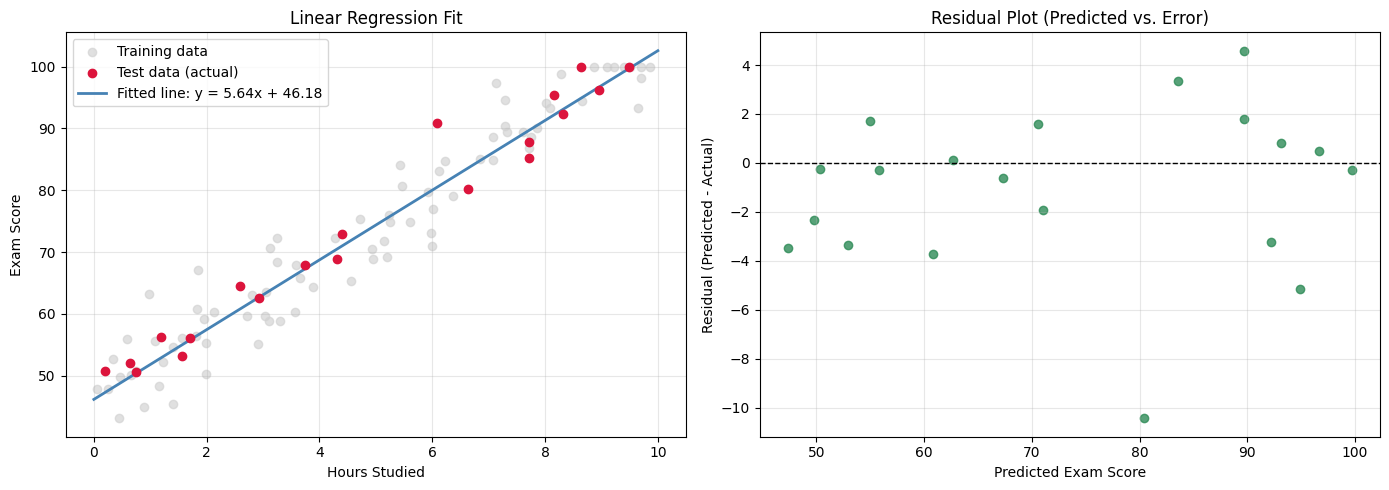

Left plot:  the fitted line should pass reasonably through the middle of the data cloud.
Right plot: residuals should look like a random 'cloud' around the zero line, with no clear pattern.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Regression line with train/test points ---
axes[0].scatter(X_train, y_train, color='lightgray', label='Training data', alpha=0.7)
axes[0].scatter(X_test, y_test, color='crimson', label='Test data (actual)', zorder=3)

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(x_line)
axes[0].plot(x_line, y_line, color='steelblue', linewidth=2,
             label=f'Fitted line: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

axes[0].set_title("Linear Regression Fit")
axes[0].set_xlabel("Hours Studied")
axes[0].set_ylabel("Exam Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Residual plot ---
residuals = y_pred - y_test.values
axes[1].scatter(y_pred, residuals, color='seagreen', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)  # the "zero error" reference line
axes[1].set_title("Residual Plot (Predicted vs. Error)")
axes[1].set_xlabel("Predicted Exam Score")
axes[1].set_ylabel("Residual (Predicted - Actual)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left plot:  the fitted line should pass reasonably through the middle of the data cloud.")
print("Right plot: residuals should look like a random 'cloud' around the zero line, with no clear pattern.")


## Step 6: From-Scratch vs. scikit-learn — Side by Side

| Aspect | From Scratch (Hour 2) | scikit-learn (Hour 3) |
|---|---|---|
| Model equation | Wrote $\hat{y} = wx + b$ manually | Same equation, handled internally |
| Loss function | Coded MSE manually | Computed internally during `.fit()` |
| Optimization | Wrote gradient descent loop manually | `.fit()` uses an efficient internal solver |
| Speed | Slow for large data (pure Python loops) | Highly optimized (C/Fortran under the hood) |
| Best for | **Learning and understanding** the math | **Real projects** and production use |

**Why did we do BOTH?** Understanding the "from scratch" version means you'll never treat `model.fit()` as magic — you now know it's really just gradient descent minimizing MSE, exactly like we coded by hand.


### Practice Exercises (try before next class)
1. Change the `learning_rate` in the from-scratch section to `0.1` and then to `0.0001`. Re-run and observe the loss curve — what happens?
2. Add a second feature (e.g., `hours_slept`) to the synthetic dataset and retrain the scikit-learn model.
3. Try setting `test_size=0.5` instead of `0.2` — how do the evaluation metrics change, and why?
4. Look at the residual plot again — do you see any pattern, or does it look randomly scattered? What would a pattern suggest about our model?

### Next Lecture Preview
We'll move from **regression** (predicting numbers) to **classification** (predicting categories), starting with **Logistic Regression** — which reuses almost everything you learned today!


### Overfitting, Underfitting or Perfect

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Ensuring our random simulations look identical on everyone's screens
np.random.seed(15)
print("Environment ready! All data science toolkits loaded.")

Environment ready! All data science toolkits loaded.


In [16]:
# 1. Generate true underlying curved data (a sine wave)
def true_trend(X):
    return np.sin(1.5 * np.pi * X)

# Generate 30 random sample points with some added real-world noise
n_samples = 30
X_data = np.sort(np.random.rand(n_samples))
y_data = true_trend(X_data) + np.random.randn(n_samples) * 0.15 # 0.15 is our noise factor

# Reshape for scikit-learn format
X_data = X_data[:, np.newaxis]

print(f"Generated {n_samples} messy, real-world data points for training.")

Generated 30 messy, real-world data points for training.


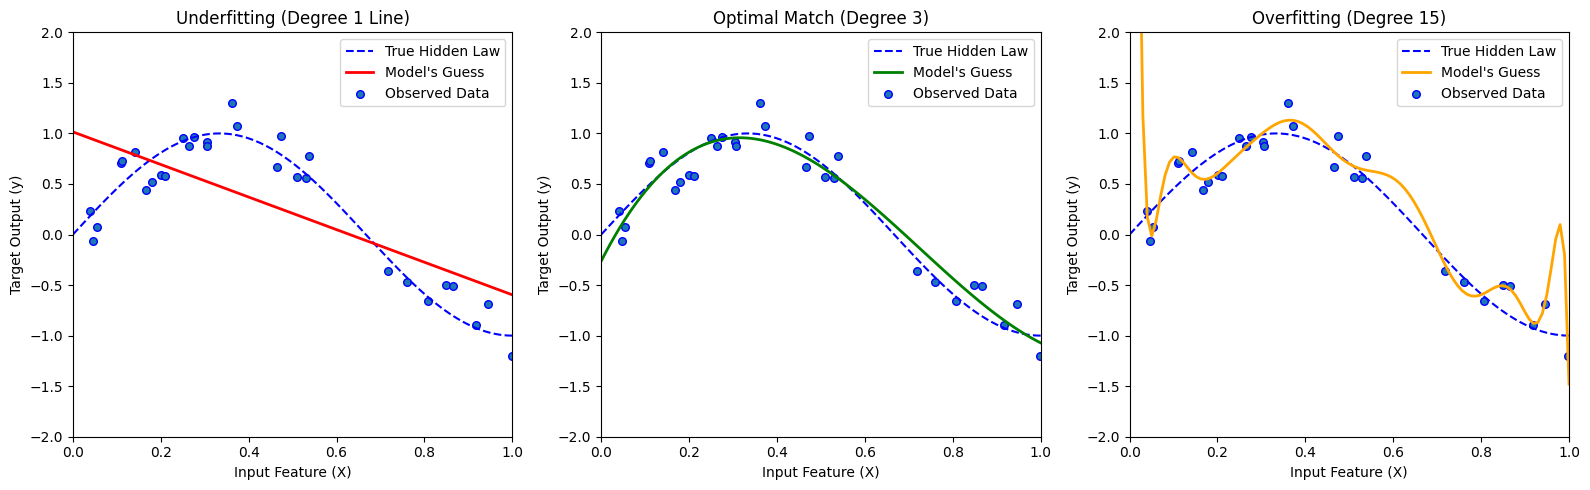

In [17]:
# We will fit three models: Simple Line (Underfit), Degree 3 Curve (Perfect), Degree 15 Curve (Overfit)
degrees = [1, 3, 15]
titles = ["Underfitting (Degree 1 Line)", "Optimal Match (Degree 3)", "Overfitting (Degree 15)"]
colors = ['red', 'green', 'orange']

plt.figure(figsize=(16, 5))
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    
    # Create and train the pipeline model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()) # PF: calculates $x^2$ and $x^3$, turning a single column input into multiple columns. LR: Estimator.
    model.fit(X_data, y_data)
    
    # Plot the results
    plt.plot(X_plot, true_trend(X_plot), label="True Hidden Law", color='blue', linestyle='--')
    plt.plot(X_plot, model.predict(X_plot), label="Model's Guess", color=colors[i], lw=2)
    plt.scatter(X_data, y_data, edgecolor='b', s=30, label="Observed Data")
    
    plt.xlabel("Input Feature (X)")
    plt.ylabel("Target Output (y)")
    plt.xlim(0, 1)
    plt.ylim(-2, 2)
    plt.title(titles[i])
    plt.legend(loc="best")

plt.tight_layout()
plt.show()